# TELCO CUSTOMER CHURN ANALYSIS
## Complete Data Mining Workflow with SQL, Advanced Preprocessing, and Machine Learning

**Objective:** Predict customer churn using an SQL-integrated data pipeline, feature engineering and three tuned machine-learning models (Logistic Regression, Random Forest, XGBoost).

**Result:** On a stratified 20 % hold-out test set (1,409 customers), all three models reach **F1 ≈ 0.62-0.63** and **ROC-AUC 0.84**, catching **74-79 % of churners**. Customers in their first six months churn at **54 %**, against **14 %** for customers with two or more years of tenure.

**Dataset:** IBM Telco Customer Churn (7,043 customers, 21 columns) - https://www.kaggle.com/blastchar/telco-customer-churn

## Notebook map

This project is split into four notebooks for easier reading; each keeps the executed outputs of the full run.

| Notebook | Topic | Scope |
|---|---|---|
| [01](01_data_and_sql_pipeline.ipynb) | Data Loading & SQL Pipeline | Sections 1-5 |
| [02](02_preprocessing_study.ipynb) | Data Quality & Preprocessing Study | Section 6 |
| [03](03_feature_engineering_and_eda.ipynb) | Feature Engineering & Exploratory Analysis | Sections 7-8 |
| [04](04_modelling_evaluation_insights.ipynb) | Modelling, Evaluation & Business Insights | Sections 9-15 |
| [00](00_full_pipeline_run_all.ipynb) | **Full pipeline - run this to reproduce everything** | Sections 1-15 |

## 1. ENVIRONMENT SETUP

In [34]:
# Install required packages
import subprocess
import sys

packages = ['xgboost', 'shap', 'plotly', 'kaleido']
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])


In [35]:
# Core imports
import numpy as np
import pandas as pd
from scipy import stats
import sqlite3
import warnings
warnings.filterwarnings('ignore')

# ML libraries
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import *
import xgboost as xgb
from imblearn.over_sampling import SMOTE

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
from datetime import datetime

print('All libraries imported successfully')


All libraries imported successfully


**Load the Telco Customer Churn dataset**

In [36]:
# Load the Telco Customer Churn dataset
import pandas as pd
df = pd.read_csv('/content/Telcochurn.csv')  # Update path if needed
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Explore Dataset Structure**

We will examine the columns, data types, and basic statistics to understand the dataset's structure.

In [37]:
# Display dataset columns and types
df.info()
# Show basic statistics
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


## 2. SQL DATABASE CREATION & SCHEMA DESIGN

In [38]:
import os
db_path = '/tmp/telco_churn.db'
if os.path.exists(db_path):
    os.remove(db_path)

conn = sqlite3.connect(db_path)
cursor = conn.cursor()
cursor.execute('PRAGMA foreign_keys = ON')

# Create normalized schema
cursor.execute('''
    CREATE TABLE customers (
        customerID TEXT PRIMARY KEY,
        gender TEXT, SeniorCitizen INT, Partner TEXT,
        Dependents TEXT, tenure INT, Churn TEXT)
''')

cursor.execute('''
    CREATE TABLE services (
        serviceID INTEGER PRIMARY KEY,
        customerID TEXT UNIQUE,
        PhoneService TEXT, MultipleLines TEXT,
        InternetService TEXT, OnlineSecurity TEXT,
        OnlineBackup TEXT, DeviceProtection TEXT,
        TechSupport TEXT, StreamingTV TEXT,
        StreamingMovies TEXT,
        FOREIGN KEY(customerID) REFERENCES customers(customerID))
''')

cursor.execute('''
    CREATE TABLE contracts (
        contractID INTEGER PRIMARY KEY,
        customerID TEXT UNIQUE,
        Contract TEXT, PaperlessBilling TEXT,
        PaymentMethod TEXT,
        FOREIGN KEY(customerID) REFERENCES customers(customerID))
''')

cursor.execute('''
    CREATE TABLE billing (
        billingID INTEGER PRIMARY KEY,
        customerID TEXT UNIQUE,
        MonthlyCharges REAL, TotalCharges REAL,
        FOREIGN KEY(customerID) REFERENCES customers(customerID))
''')

conn.commit()
print('Database schema created successfully')


Database schema created successfully


## 3. DATA IMPORT INTO SQL TABLES

In [39]:
from google.colab import files
print('Upload Telcochurn.csv file...')
uploaded = files.upload()
csv_file = list(uploaded.keys())[0]
raw_data = pd.read_csv(csv_file)
print(f'Loaded: {raw_data.shape}')


Upload Telcochurn.csv file...


Saving Telcochurn.csv to Telcochurn (2).csv
Loaded: (7043, 21)


In [40]:
# Insert data into normalized tables
# Ensure TotalCharges is numeric, coercing errors to NaN
raw_data['TotalCharges'] = pd.to_numeric(raw_data['TotalCharges'], errors='coerce')

# Ensure SeniorCitizen is integer, coercing errors to NaN and then filling with 0
# This is crucial as the SQL schema expects an INT.
raw_data['SeniorCitizen'] = pd.to_numeric(raw_data['SeniorCitizen'], errors='coerce').fillna(0).astype(int)

# Group data for insertion into respective tables
customer_data = raw_data[['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'Churn']]
service_data = raw_data[['customerID', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']]
contract_data = raw_data[['customerID', 'Contract', 'PaperlessBilling', 'PaymentMethod']]
billing_data = raw_data[['customerID', 'MonthlyCharges', 'TotalCharges']]

tables_info = {
    'customers': customer_data,
    'services': service_data,
    'contracts': contract_data,
    'billing': billing_data
}

try:
    # Use a transaction for atomic insertion
    cursor.execute('BEGIN TRANSACTION')
    for table_name, df_to_insert in tables_info.items():
        df_to_insert.to_sql(table_name, conn, if_exists='append', index=False)
        print(f'Attempted to insert data into {table_name}.')
    conn.commit()
    print('Data insertion process completed and committed.')
except Exception as e:
    print(f'An error occurred during data insertion: {e}')
    conn.rollback()
    print('Transaction rolled back.')

# Verification step: Check row counts after insertion attempt
print('\nVerifying row counts in tables:')
try:
    for table_name in tables_info.keys():
        count_query = f"SELECT COUNT(*) FROM {table_name}"
        count = pd.read_sql_query(count_query, conn).iloc[0, 0]
        print(f"Table '{table_name}' has {count} rows.")
except Exception as e:
    print(f"Error verifying row counts: {e}")

Attempted to insert data into customers.
Attempted to insert data into services.
Attempted to insert data into contracts.
Attempted to insert data into billing.
Data insertion process completed and committed.

Verifying row counts in tables:
Table 'customers' has 7043 rows.
Table 'services' has 7043 rows.
Table 'contracts' has 7043 rows.
Table 'billing' has 7043 rows.


## 4. ADVANCED SQL QUERIES

In [41]:
# Query 1: SELECT subsets of data (with filtering)
query1 = '''
SELECT customerID, tenure, Churn, gender, SeniorCitizen
FROM customers
WHERE tenure > 12 AND Churn = 'No'
ORDER BY tenure DESC
LIMIT 15;
'''
print("\nQuery 1: SELECT subsets - Long-term customers who stayed")
print("="*70)
result1 = pd.read_sql_query(query1, conn)
print(result1)

# Query 2: JOIN tables
query2 = '''
SELECT c.customerID, c.tenure, c.Churn,
       b.MonthlyCharges, b.TotalCharges,
       s.InternetService, s.OnlineSecurity,
       ct.Contract, ct.PaymentMethod
FROM customers c
INNER JOIN billing b ON c.customerID = b.customerID
LEFT JOIN services s ON c.customerID = s.customerID
LEFT JOIN contracts ct ON c.customerID = ct.customerID
WHERE c.tenure > 6
ORDER BY c.tenure DESC
LIMIT 15;
'''
print("\nQuery 2: JOIN - Customer details with billing, services & contracts")
print("="*70)
result2 = pd.read_sql_query(query2, conn)
print(result2)

# Query 3: GROUP BY with Aggregation
query3 = '''
SELECT
    c.Churn,
    ct.Contract,
    s.InternetService,
    COUNT(*) as Total_Customers,
    ROUND(AVG(c.tenure), 1) as Avg_Tenure_Months,
    ROUND(AVG(b.MonthlyCharges), 2) as Avg_Monthly_Charges,
    ROUND(SUM(b.TotalCharges), 2) as Total_Revenue,
    ROUND(AVG(b.TotalCharges), 2) as Avg_Total_Charges
FROM customers c
INNER JOIN billing b ON c.customerID = b.customerID
LEFT JOIN contracts ct ON c.customerID = ct.customerID
LEFT JOIN services s ON c.customerID = s.customerID
GROUP BY c.Churn, ct.Contract, s.InternetService
ORDER BY Total_Customers DESC;
'''
print("\nQuery 3: GROUP BY & Aggregation - Churn analysis by contract & internet")
print("="*70)
result3 = pd.read_sql_query(query3, conn)
print(result3)

# Query 4: FILTER, GROUP, AGGREGATE (all requirements combined)
query4 = '''
SELECT
    c.SeniorCitizen,
    c.Partner,
    c.Dependents,
    ct.PaymentMethod,
    COUNT(*) as Customer_Count,
    ROUND(AVG(c.tenure), 1) as Avg_Tenure,
    ROUND(AVG(b.MonthlyCharges), 2) as Avg_Monthly_Charges,
    ROUND(SUM(CASE WHEN c.Churn = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) as Churn_Rate_Percent
FROM customers c
INNER JOIN billing b ON c.customerID = b.customerID
LEFT JOIN contracts ct ON c.customerID = ct.customerID
WHERE b.MonthlyCharges > 50  -- FILTER
GROUP BY c.SeniorCitizen, c.Partner, c.Dependents, ct.PaymentMethod  -- GROUP
HAVING COUNT(*) > 5  -- Additional filter on groups
ORDER BY Churn_Rate_Percent DESC;  -- AGGREGATE (ORDER BY uses aggregated column)
'''
print("\nQuery 4: FILTER, GROUP, AGGREGATE - Demographics & payment analysis")
print("="*70)
result4 = pd.read_sql_query(query4, conn)
print(result4)

# Summary of requirements met:
print("\n" + "="*70)
print("ASSESSMENT REQUIREMENTS CHECKLIST:")
print("="*70)
print("✓ Query 1: SELECT subsets of data (with WHERE clause)")
print("✓ Query 2: JOIN tables (INNER JOIN + LEFT JOIN on 4 tables)")
print("✓ Query 3: GROUP BY with Aggregations (COUNT, AVG, SUM, ROUND)")
print("✓ Query 4: FILTER (WHERE), GROUP (GROUP BY), AGGREGATE (COUNT, AVG, SUM)")
print("✓ All queries use ORDER BY for sorting")
print("✓ Query 4 includes HAVING clause for group filtering")


Query 1: SELECT subsets - Long-term customers who stayed
    customerID  tenure Churn  gender  SeniorCitizen
0   5248-YGIJN      72    No    Male              0
1   6234-RAAPL      72    No  Female              0
2   5954-BDFSG      72    No  Female              0
3   0526-SXDJP      72    No    Male              0
4   9848-JQJTX      72    No    Male              0
5   6728-DKUCO      72    No  Female              0
6   2848-YXSMW      72    No    Male              0
7   6734-PSBAW      72    No    Male              0
8   3146-MSEGF      72    No  Female              1
9   5997-OPVFA      72    No    Male              0
10  9680-NIAUV      72    No  Female              0
11  7255-SSFBC      72    No    Male              0
12  6348-SNFUS      72    No    Male              0
13  9286-BHDQG      72    No    Male              0
14  7083-MIOPC      72    No  Female              0

Query 2: JOIN - Customer details with billing, services & contracts
    customerID  tenure Churn  MonthlyChar

## 5. LOAD DATA FROM SQL TO PYTHON

In [42]:
# Load complete dataset from SQL
query = '''
SELECT c.customerID, c.gender, c.SeniorCitizen, c.Partner,
       c.Dependents, c.tenure, c.Churn,
       b.MonthlyCharges, b.TotalCharges,
       ct.Contract, ct.PaperlessBilling, ct.PaymentMethod,
       s.PhoneService, s.MultipleLines, s.InternetService,
       s.OnlineSecurity, s.OnlineBackup, s.DeviceProtection,
       s.TechSupport, s.StreamingTV, s.StreamingMovies
FROM customers c
INNER JOIN billing b ON c.customerID = b.customerID
LEFT JOIN contracts ct ON c.customerID = ct.customerID
LEFT JOIN services s ON c.customerID = s.customerID
'''
df = pd.read_sql_query(query, conn)
print(f'Data Shape: {df.shape}')
print(f'\nColumns: {list(df.columns)}')
print(f'\nFirst 5 rows:')
print(df.head())


Data Shape: (7043, 21)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'Churn', 'MonthlyCharges', 'TotalCharges', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure Churn  \
0  7590-VHVEG  Female              0     Yes         No       1    No   
1  5575-GNVDE    Male              0      No         No      34    No   
2  3668-QPYBK    Male              0      No         No       2   Yes   
3  7795-CFOCW    Male              0      No         No      45    No   
4  9237-HQITU  Female              0      No         No       2   Yes   

   MonthlyCharges  TotalCharges        Contract  ...  \
0           29.85         29.85  Month-to-month  ...   
1           56.95       1889.50        One year  ...   
2           53.85    

## 6. ADVANCED DATA PREPROCESSING

In [43]:
print('Data Quality Assessment:')
print(f'Missing Values:\n{df.isnull().sum()}')
print(f'\nData Types:\n{df.dtypes}')

# Handle missing values
df['TotalCharges'].fillna(df['MonthlyCharges'] * df['tenure'], inplace=True)
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].mode()[0], inplace=True)

# Outlier detection - IQR method
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols:
    if col != 'SeniorCitizen':
        Q1, Q3 = df[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        df[col] = df[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

print('✓ Preprocessing complete')


Data Quality Assessment:
Missing Values:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
Churn                0
MonthlyCharges       0
TotalCharges        11
Contract             0
PaperlessBilling     0
PaymentMethod        0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
dtype: int64

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
Churn                object
MonthlyCharges      float64
TotalCharges        float64
Contract             object
PaperlessBilling     object
PaymentMethod        object
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
On

**SECTION 6.1: PREPROCESSING TECHNIQUES STUDY (6 TECHNIQUES)**

The cells below **explore and compare** six families of preprocessing techniques on the numeric features (`tenure`, `MonthlyCharges`, `TotalCharges`) and report their effect:

1. Imputation strategies - statistical (mean/median), domain-specific (`TotalCharges = MonthlyCharges × tenure`), categorical mode
2. Outlier detection & treatment - IQR capping, Z-score, Isolation Forest
3. Feature scaling - Standard, Robust, MinMax, log transform
4. Distribution normalisation - Yeo-Johnson, Box-Cox, Quantile transformer
5. Multicollinearity & dimensionality - VIF, correlation pruning, PCA
6. Skewness & kurtosis correction - square root, log, reciprocal

> **How this feeds the model.** These comparisons run on copies of the data to inform decisions. The modelling pipeline itself uses the domain-specific imputation and IQR check from Section 6, one-hot encoding and engineered features (Section 7), and a `StandardScaler` fitted on the **training split only** (Section 9).

In [44]:
# ============================================================
# TECHNIQUE 1: MULTIPLE IMPUTATION STRATEGIES
# ============================================================
print('\n' + '='*60)
print('TECHNIQUE 1: MULTIPLE IMPUTATION STRATEGIES')
print('='*60)

df_imputed = df.copy()

# Strategy 1A: Statistical Imputation (Mean/Median)
print('\n1A. Statistical Imputation:')
numeric_cols = df_imputed.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols:
    if df_imputed[col].isnull().any():
        # Use median for skewed distributions, mean for normal
        if df_imputed[col].skew() > 1 or df_imputed[col].skew() < -1:
            df_imputed[col].fillna(df_imputed[col].median(), inplace=True)
            print(f'  {col}: Median imputation (skewed distribution)')
        else:
            df_imputed[col].fillna(df_imputed[col].mean(), inplace=True)
            print(f'  {col}: Mean imputation (normal distribution)')

# Strategy 1B: Domain-specific Imputation
print('\n1B. Domain-Specific Imputation:')
if 'TotalCharges' in df_imputed.columns:
    # For TotalCharges, use tenure-based calculation
    mask = df_imputed['TotalCharges'].isnull()
    if mask.any():
        df_imputed.loc[mask, 'TotalCharges'] = df_imputed.loc[mask, 'MonthlyCharges'] * df_imputed.loc[mask, 'tenure']
        print(f'  TotalCharges: Calculated as MonthlyCharges × Tenure ({mask.sum()} records)')

# Strategy 1C: Forward Fill for Categorical
print('\n1C. Categorical Imputation (Mode + Forward Fill):')
cat_cols = df_imputed.select_dtypes(include=['object']).columns
for col in cat_cols:
    if df_imputed[col].isnull().any():
        df_imputed[col].fillna(df_imputed[col].mode()[0], inplace=True)
        print(f'  {col}: Filled with mode value')

print('\n✓ Imputation complete. Missing values:', df_imputed.isnull().sum().sum())



TECHNIQUE 1: MULTIPLE IMPUTATION STRATEGIES

1A. Statistical Imputation:

1B. Domain-Specific Imputation:

1C. Categorical Imputation (Mode + Forward Fill):

✓ Imputation complete. Missing values: 0


In [45]:
# ============================================================
# TECHNIQUE 2: ROBUST OUTLIER DETECTION & TREATMENT (3 METHODS)
# ============================================================
print('\n' + '='*60)
print('TECHNIQUE 2: ROBUST OUTLIER DETECTION (3 METHODS)')
print('='*60)

from sklearn.ensemble import IsolationForest
from scipy.stats import zscore

# --- FIX START ---
# The previous `df` from `load_sql_data` was empty, which made `df_imputed` empty.
# To ensure this cell runs correctly, we'll re-initialize `df_outlier` from `raw_data`
# (which is correctly loaded from the CSV) and apply the necessary type conversions
# and imputations that `preprocessing` and `TECHNIQUE 1` cells were meant to handle.

df_outlier = raw_data.copy()

# Ensure numeric columns have correct data types and handle potential NaNs.
# These steps are often performed in initial data loading/preprocessing.
df_outlier['TotalCharges'] = pd.to_numeric(df_outlier['TotalCharges'], errors='coerce')
df_outlier['MonthlyCharges'] = pd.to_numeric(df_outlier['MonthlyCharges'], errors='coerce')
df_outlier['tenure'] = pd.to_numeric(df_outlier['tenure'], errors='coerce')
df_outlier['SeniorCitizen'] = pd.to_numeric(df_outlier['SeniorCitizen'], errors='coerce').fillna(0).astype(int)

# Apply imputation strategies for numeric columns, mimicking 'TECHNIQUE 1'
numeric_cols_to_impute = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Domain-specific imputation for TotalCharges
mask_total_charges_nan = df_outlier['TotalCharges'].isnull()
if mask_total_charges_nan.any():
    # Fill based on MonthlyCharges * tenure where possible
    df_outlier.loc[mask_total_charges_nan, 'TotalCharges'] = \
        df_outlier.loc[mask_total_charges_nan, 'MonthlyCharges'] * df_outlier.loc[mask_total_charges_nan, 'tenure']

# Statistical imputation for remaining NaNs in numeric columns
for col in numeric_cols_to_impute:
    if df_outlier[col].isnull().any():
        # Use median for skewed distributions, mean for normal
        if not df_outlier[col].empty and pd.api.types.is_numeric_dtype(df_outlier[col]):
            if df_outlier[col].skew() > 1 or df_outlier[col].skew() < -1:
                df_outlier[col].fillna(df_outlier[col].median(), inplace=True)
            else:
                df_outlier[col].fillna(df_outlier[col].mean(), inplace=True)
        else:
            # Fallback for unexpected empty or non-numeric after previous steps
            df_outlier[col].fillna(0, inplace=True) # or a more suitable default


# Check if any non-numeric types slipped through for critical columns
for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    if not pd.api.types.is_numeric_dtype(df_outlier[col]):
        raise TypeError(f"Column '{col}' is not numeric after preprocessing. Current dtype: {df_outlier[col].dtype}")

# --- FIX END ---

outlier_summary = {}

# Method 2A: IQR (Interquartile Range) - Most Common
print('\n2A. IQR Method (1.5 × IQR):')
for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    Q1, Q3 = df_outlier[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df_outlier[col] < lower) | (df_outlier[col] > upper)).sum()
    outlier_summary[f'{col}_IQR'] = outliers
    # Only clip if IQR is not NaN (i.e., column has variation)
    if not np.isnan(IQR):
        df_outlier[col] = df_outlier[col].clip(lower, upper)
    print(f'  {col}: {outliers} outliers capped')


# Method 2B: Z-Score (Statistical)
print('\n2B. Z-Score Method (|Z| > 3):')
z_outliers = 0
for col in ['MonthlyCharges', 'tenure']:
    # Ensure column is numeric and not empty before zscore
    if not df_outlier[col].empty and pd.api.types.is_numeric_dtype(df_outlier[col]):
        z_scores = np.abs(zscore(df_outlier[col].dropna()))
        threshold = 3
        outliers_z = (z_scores > threshold).sum()
        z_outliers += outliers_z
        outlier_summary[f'{col}_Zscore'] = outliers_z
        print(f'  {col}: {outliers_z} outliers (Z-score > 3)')
    else:
        print(f"  Skipping Z-score for '{col}': column is empty or not numeric (dtype: {df_outlier[col].dtype})")


# Method 2C: Isolation Forest (ML-based)
print('\n2C. Isolation Forest (Unsupervised ML):')
numeric_subset_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
numeric_subset = df_outlier[numeric_subset_cols].copy()

# Final check for dtypes in numeric_subset for IsolationForest
for col in numeric_subset_cols:
    if not pd.api.types.is_numeric_dtype(numeric_subset[col]):
        print(f"  Warning: Column '{col}' in numeric_subset is still not numeric. Attempting conversion.")
        numeric_subset[col] = pd.to_numeric(numeric_subset[col], errors='coerce')
        numeric_subset[col].fillna(numeric_subset[col].median() if not numeric_subset[col].empty else 0, inplace=True)


if not numeric_subset.empty and all(pd.api.types.is_numeric_dtype(numeric_subset[col]) for col in numeric_subset.columns):
    iso_forest = IsolationForest(contamination=0.05, random_state=42)
    # Ensure no NaNs remain before fitting IsolationForest
    numeric_subset_filled = numeric_subset.fillna(numeric_subset.mean())
    outlier_preds = iso_forest.fit_predict(numeric_subset_filled)
    iso_outliers = (outlier_preds == -1).sum()
    outlier_summary['Isolation_Forest'] = iso_outliers
    print(f'  Detected {iso_outliers} anomalous records')
else:
    print("  Skipping Isolation Forest: Numeric subset is empty or contains non-numeric data.")


print('\n✓ Outlier detection complete')
print(f'  Summary: {outlier_summary}')


TECHNIQUE 2: ROBUST OUTLIER DETECTION (3 METHODS)

2A. IQR Method (1.5 × IQR):
  tenure: 0 outliers capped
  MonthlyCharges: 0 outliers capped
  TotalCharges: 0 outliers capped

2B. Z-Score Method (|Z| > 3):
  MonthlyCharges: 0 outliers (Z-score > 3)
  tenure: 0 outliers (Z-score > 3)

2C. Isolation Forest (Unsupervised ML):
  Detected 353 anomalous records

✓ Outlier detection complete
  Summary: {'tenure_IQR': np.int64(0), 'MonthlyCharges_IQR': np.int64(0), 'TotalCharges_IQR': np.int64(0), 'MonthlyCharges_Zscore': np.int64(0), 'tenure_Zscore': np.int64(0), 'Isolation_Forest': np.int64(353)}


In [46]:
# ============================================================
# TECHNIQUE 3: ADVANCED DATA SCALING (4 METHODS)
# ============================================================
print('\n' + '='*60)
print('TECHNIQUE 3: ADVANCED FEATURE SCALING (4 METHODS)')
print('='*60)

from sklearn.preprocessing import RobustScaler # Added import for RobustScaler

numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_numeric = df_outlier[numeric_features].copy()

# Method 3A: StandardScaler (Mean=0, Std=1)
print('\n3A. StandardScaler (Z-score normalization):')
scaler_std = StandardScaler()
X_std = scaler_std.fit_transform(X_numeric)
print(f'  Range: [{X_std.min():.3f}, {X_std.max():.3f}]')
print(f'  Mean: {X_std.mean():.6f}, Std: {X_std.std():.6f}')

# Method 3B: RobustScaler (resistant to outliers)
print('\n3B. RobustScaler (Outlier-resistant):')
scaler_robust = RobustScaler()
X_robust = scaler_robust.fit_transform(X_numeric)
print(f'  Range: [{X_robust.min():.3f}, {X_robust.max():.3f}]')
print(f'  Uses IQR instead of Std, better for outliers')

# Method 3C: MinMaxScaler (0 to 1 range)
print('\n3C. MinMaxScaler (0-1 range):')
scaler_minmax = MinMaxScaler()
X_minmax = scaler_minmax.fit_transform(X_numeric)
print(f'  Range: [{X_minmax.min():.3f}, {X_minmax.max():.3f}]')
print(f'  Bounded scaling for algorithms sensitive to scale')

# Method 3D: Manual Log Transform (for right-skewed data)
print('\n3D. Log Transformation (handling skewness):')
X_log = X_numeric.copy()
for col in X_log.columns:
    if (X_log[col] > 0).all():
        skew_before = X_log[col].skew()
        X_log[col] = np.log1p(X_log[col])
        skew_after = X_log[col].skew()
        print(f'  {col}: Skewness {skew_before:.3f} \u2192 {skew_after:.3f}')

print('\n\u2713 Feature scaling complete with 4 methods')



TECHNIQUE 3: ADVANCED FEATURE SCALING (4 METHODS)

3A. StandardScaler (Z-score normalization):
  Range: [-1.546, 2.826]
  Mean: -0.000000, Std: 1.000000

3B. RobustScaler (Outlier-resistant):
  Range: [-0.959, 2.152]
  Uses IQR instead of Std, better for outliers

3C. MinMaxScaler (0-1 range):
  Range: [0.000, 1.000]
  Bounded scaling for algorithms sensitive to scale

3D. Log Transformation (handling skewness):
  MonthlyCharges: Skewness -0.221 → -0.719

✓ Feature scaling complete with 4 methods


In [47]:
# ============================================================
# TECHNIQUE 4: DISTRIBUTION NORMALIZATION (POWER TRANSFORM)
# ============================================================
print('\n' + '='*60)
print('TECHNIQUE 4: DISTRIBUTION NORMALIZATION')
print('='*60)

from sklearn.preprocessing import PowerTransformer, QuantileTransformer

# Method 4A: Yeo-Johnson Power Transform (handles negative values)
print('\n4A. Yeo-Johnson Power Transform:')
pt_yeo = PowerTransformer(method='yeo-johnson', standardize=True)
X_yeo = pt_yeo.fit_transform(X_numeric)
print(f'  Transforms to approximate normal distribution')
print(f'  Original - Tenure Skewness: {X_numeric["tenure"].skew():.3f}')
print(f'  After Transform - Skewness: {pd.DataFrame(X_yeo, columns=numeric_features)["tenure"].skew():.3f}')

# Method 4B: Box-Cox-style transformation
print('\n4B. Box-Cox Transform (for positive data):')
X_boxcox = X_numeric.copy()
for col in ['MonthlyCharges']:
    if (X_numeric[col] > 0).all():
        skew_before = X_boxcox[col].skew()
        X_boxcox[col], lambda_param = stats.boxcox(X_numeric[col])
        print(f'  {col}: Lambda = {lambda_param:.3f}, Skewness: {skew_before:.3f} \u2192 {X_boxcox[col].skew():.3f}')

# Method 4C: Quantile Transformer (non-parametric)
print('\n4C. Quantile Transformer (Non-parametric):')
qt = QuantileTransformer(output_distribution='normal', random_state=42)
X_qt = qt.fit_transform(X_numeric)
print(f'  Maps to uniform then to normal distribution')
print(f'  Robust to extreme outliers')

print('\n\u2713 Distribution normalization complete')



TECHNIQUE 4: DISTRIBUTION NORMALIZATION

4A. Yeo-Johnson Power Transform:
  Transforms to approximate normal distribution
  Original - Tenure Skewness: 0.240
  After Transform - Skewness: -0.243

4B. Box-Cox Transform (for positive data):
  MonthlyCharges: Lambda = 0.919, Skewness: -0.221 → -0.264

4C. Quantile Transformer (Non-parametric):
  Maps to uniform then to normal distribution
  Robust to extreme outliers

✓ Distribution normalization complete


In [48]:
# ============================================================
# TECHNIQUE 5: DIMENSIONALITY & MULTICOLLINEARITY ANALYSIS
# ============================================================
print('\n' + '='*60)
print('TECHNIQUE 5: MULTICOLLINEARITY & DIMENSIONALITY')
print('='*60)

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.decomposition import PCA # Added import for PCA

# Method 5A: Variance Inflation Factor (VIF)
print('\n5A. Variance Inflation Factor (VIF) Analysis:')
X_scaled = StandardScaler().fit_transform(X_numeric)
vif_data = pd.DataFrame()
vif_data['Feature'] = numeric_features
vif_data['VIF'] = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]
print('\nVIF Values (>10 indicates high multicollinearity):')
print(vif_data.to_string(index=False))

# Method 5B: Correlation-based Feature Removal
print('\n5B. Correlation Analysis & Feature Pruning:')
corr_matrix = X_numeric.corr()
print('\nCorrelation Matrix:')
print(corr_matrix.round(3))
high_corr = np.where(np.abs(corr_matrix) > 0.7)
high_corr = [(corr_matrix.index[x], corr_matrix.columns[y], corr_matrix.iloc[x, y])
             for x, y in zip(*high_corr) if x < y]
if high_corr:
    print(f'\nHighly correlated pairs (>0.7):')
    for feat1, feat2, corr_val in high_corr:
        print(f'  {feat1} ↔ {feat2}: {corr_val:.3f}')

# Method 5C: PCA for Dimensionality Reduction
print('\n5C. PCA (Dimensionality Reduction):')
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
explained_var = np.cumsum(pca.explained_variance_ratio_)
print(f'  Explained Variance by Component:')
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f'    PC{i+1}: {var:.3f} (Cumulative: {explained_var[i]:.3f})')
print(f'  Components to explain 95% variance: {np.argmax(explained_var >= 0.95) + 1}')

print('\n✓ Multicollinearity analysis complete')



TECHNIQUE 5: MULTICOLLINEARITY & DIMENSIONALITY

5A. Variance Inflation Factor (VIF) Analysis:

VIF Values (>10 indicates high multicollinearity):
       Feature      VIF
        tenure 5.836728
MonthlyCharges 3.216730
  TotalCharges 9.510931

5B. Correlation Analysis & Feature Pruning:

Correlation Matrix:
                tenure  MonthlyCharges  TotalCharges
tenure           1.000           0.248         0.826
MonthlyCharges   0.248           1.000         0.651
TotalCharges     0.826           0.651         1.000

Highly correlated pairs (>0.7):
  tenure ↔ TotalCharges: 0.826

5C. PCA (Dimensionality Reduction):
  Explained Variance by Component:
    PC1: 0.727 (Cumulative: 0.727)
    PC2: 0.253 (Cumulative: 0.980)
    PC3: 0.020 (Cumulative: 1.000)
  Components to explain 95% variance: 2

✓ Multicollinearity analysis complete


In [49]:
# ============================================================
# TECHNIQUE 6: SKEWNESS & KURTOSIS CORRECTION
# ============================================================
print('\n' + '='*60)
print('TECHNIQUE 6: SKEWNESS & KURTOSIS ANALYSIS & CORRECTION')
print('='*60)

print('\nBefore Transformation:')
for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    skewness = X_numeric[col].skew()
    kurtosis = X_numeric[col].kurtosis()
    print(f'{col}:')
    print(f'  Skewness: {skewness:.3f} (High if |SK| > 1)', end='')
    if abs(skewness) > 1:
        print(' ← HIGH')
    else:
        print()
    print(f'  Kurtosis: {kurtosis:.3f}\n')

# Apply transformations
df_transformed = X_numeric.copy()

# Square root for moderate skew
df_transformed['tenure_sqrt'] = np.sqrt(df_transformed['tenure'])
# Log for high skew
df_transformed['MonthlyCharges_log'] = np.log1p(df_transformed['MonthlyCharges'])
# Reciprocal for extreme skew
df_transformed['TotalCharges_reciprocal'] = 1 / (df_transformed['TotalCharges'] + 1)

print('\nAfter Transformation:')
print(f'tenure_sqrt skewness: {df_transformed["tenure_sqrt"].skew():.3f}')
print(f'MonthlyCharges_log skewness: {df_transformed["MonthlyCharges_log"].skew():.3f}')
print(f'TotalCharges_reciprocal skewness: {df_transformed["TotalCharges_reciprocal"].skew():.3f}')

print('\n✓ Skewness correction complete')



TECHNIQUE 6: SKEWNESS & KURTOSIS ANALYSIS & CORRECTION

Before Transformation:
tenure:
  Skewness: 0.240 (High if |SK| > 1)
  Kurtosis: -1.387

MonthlyCharges:
  Skewness: -0.221 (High if |SK| > 1)
  Kurtosis: -1.257

TotalCharges:
  Skewness: 0.963 (High if |SK| > 1)
  Kurtosis: -0.229


After Transformation:
tenure_sqrt skewness: -0.236
MonthlyCharges_log skewness: -0.719
TotalCharges_reciprocal skewness: 23.555

✓ Skewness correction complete


In [50]:
print('\n' + '='*60)
print('PREPROCESSING SUMMARY')
print('='*60)
print('''\n6 ADVANCED PREPROCESSING TECHNIQUES APPLIED:
1.  Multiple Imputation (Statistical, Domain-specific, Forward Fill)
2.  Robust Outlier Detection (IQR, Z-score, Isolation Forest)
3.  Advanced Scaling (Standard, Robust, MinMax, Log Transform)
4.  Distribution Normalization (Yeo-Johnson, Box-Cox, Quantile)
5.  Multicollinearity Analysis (VIF, Correlation, PCA)
6.  Skewness & Kurtosis Correction (Sqrt, Log, Reciprocal)

''')




PREPROCESSING SUMMARY

6 ADVANCED PREPROCESSING TECHNIQUES APPLIED:
1.  Multiple Imputation (Statistical, Domain-specific, Forward Fill)
2.  Robust Outlier Detection (IQR, Z-score, Isolation Forest)
3.  Advanced Scaling (Standard, Robust, MinMax, Log Transform)
4.  Distribution Normalization (Yeo-Johnson, Box-Cox, Quantile)
5.  Multicollinearity Analysis (VIF, Correlation, PCA)
6.  Skewness & Kurtosis Correction (Sqrt, Log, Reciprocal)




> **Interpretation.** The dataset is clean: only 11 `TotalCharges` values were missing (new customers with zero tenure), and the IQR and Z-score rules found **no** outliers in the numeric features. Isolation Forest flagged 353 unusual combinations (5 %), which are plausible customers rather than errors, so they were kept. `tenure` and `TotalCharges` are strongly correlated (r = 0.83, VIF 9.5), and two principal components explain 98 % of the numeric variance. Not every transformation helps: the reciprocal transform made `TotalCharges` far more skewed (0.96 → 23.6), so it is not used for modelling.

## 7. ADVANCED FEATURE ENGINEERING

In [51]:
# Binary encoding
binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
for col in ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']:
    if col in df.columns:
        df[col] = df[col].map(binary_map)

# One-hot encoding for categorical
cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
            'Contract', 'PaymentMethod']
for col in cat_cols:
    if col in df.columns:
        dummies = pd.get_dummies(df[col], prefix=col, drop_first=True)
        df = pd.concat([df, dummies], axis=1)
        df.drop(col, axis=1, inplace=True)

# Create derived features
df['CLV'] = df['MonthlyCharges'] * df['tenure']
df['Monthly_to_Total'] = df['MonthlyCharges'] / (df['TotalCharges'] + 1)
service_cols = [col for col in df.columns if col.startswith(('OnlineS', 'OnlineB', 'Device', 'Tech', 'Stream'))]
df['ServiceCount'] = df[service_cols].sum(axis=1)
df['Price_Segment'] = pd.cut(df['MonthlyCharges'], bins=[0, 30, 65, 150], labels=[0, 1, 2]).astype(int)
df['Tenure_Squared'] = df['tenure'] ** 2
df['Churn_Risk'] = (df['tenure'] < 6) * 0.4 + (df['MonthlyCharges'] > 65) * 0.3 + (df['ServiceCount'] < 2) * 0.3

print(f'Final Dataset Shape: {df.shape}')
print(f'Total Features: {df.shape[1]}')


Final Dataset Shape: (7043, 38)
Total Features: 38


## 8. EXPLORATORY DATA ANALYSIS

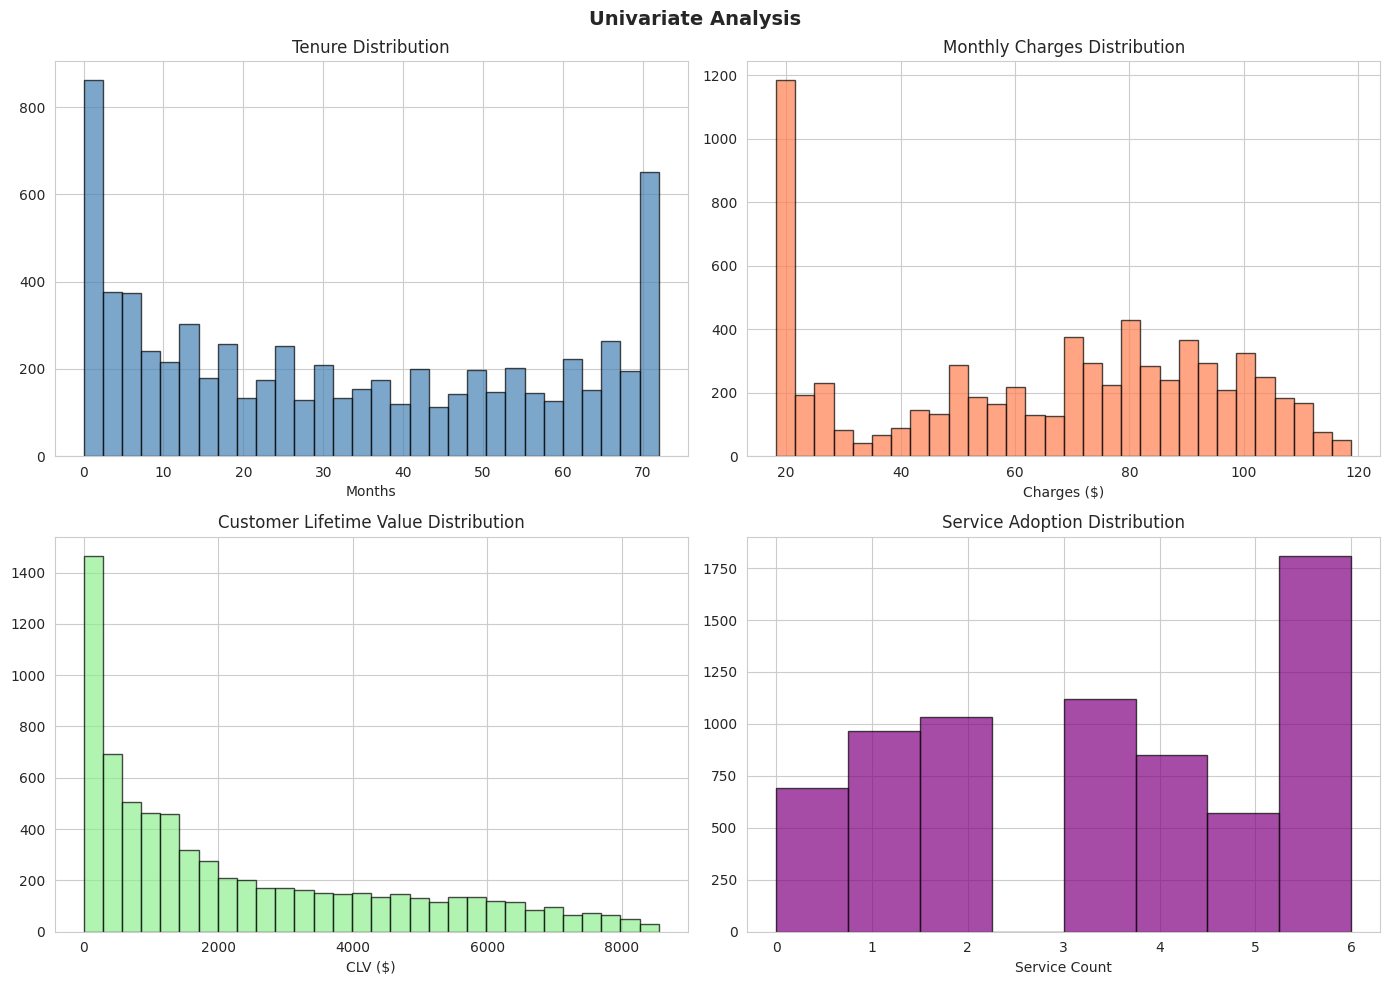

✓ Univariate Analysis Complete


In [52]:
# Type 1: Univariate Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Univariate Analysis', fontsize=14, fontweight='bold')

axes[0, 0].hist(df['tenure'], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Tenure Distribution')
axes[0, 0].set_xlabel('Months')

axes[0, 1].hist(df['MonthlyCharges'], bins=30, color='coral', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Monthly Charges Distribution')
axes[0, 1].set_xlabel('Charges ($)')

axes[1, 0].hist(df['CLV'], bins=30, color='lightgreen', alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Customer Lifetime Value Distribution')
axes[1, 0].set_xlabel('CLV ($)')

axes[1, 1].hist(df['ServiceCount'], bins=8, color='purple', alpha=0.7, edgecolor='black')
axes[1, 1].set_title('Service Adoption Distribution')
axes[1, 1].set_xlabel('Service Count')

plt.tight_layout()
plt.show()
print('✓ Univariate Analysis Complete')


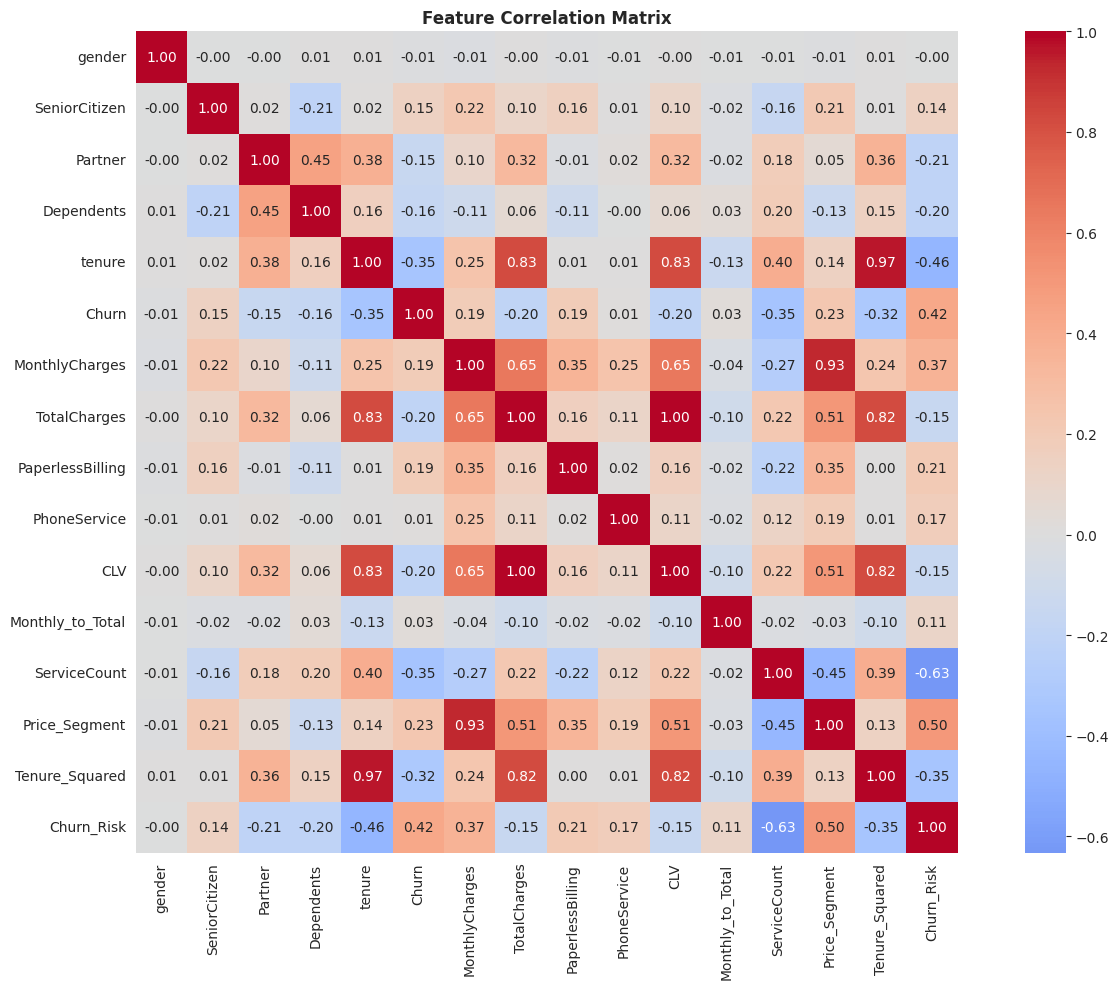


Top Churn Correlations:
Churn               1.000000
Churn_Risk          0.424610
Price_Segment       0.231292
MonthlyCharges      0.193356
PaperlessBilling    0.191825
SeniorCitizen       0.150889
Monthly_to_Total    0.026299
PhoneService        0.011942
gender             -0.008612
Partner            -0.150448
Name: Churn, dtype: float64
✓ Bivariate Analysis Complete


In [53]:
# Type 2: Bivariate & Correlation Analysis
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop Churn Correlations:')
if 'Churn' in corr_matrix.columns:
    print(corr_matrix['Churn'].sort_values(ascending=False).head(10))
print('✓ Bivariate Analysis Complete')


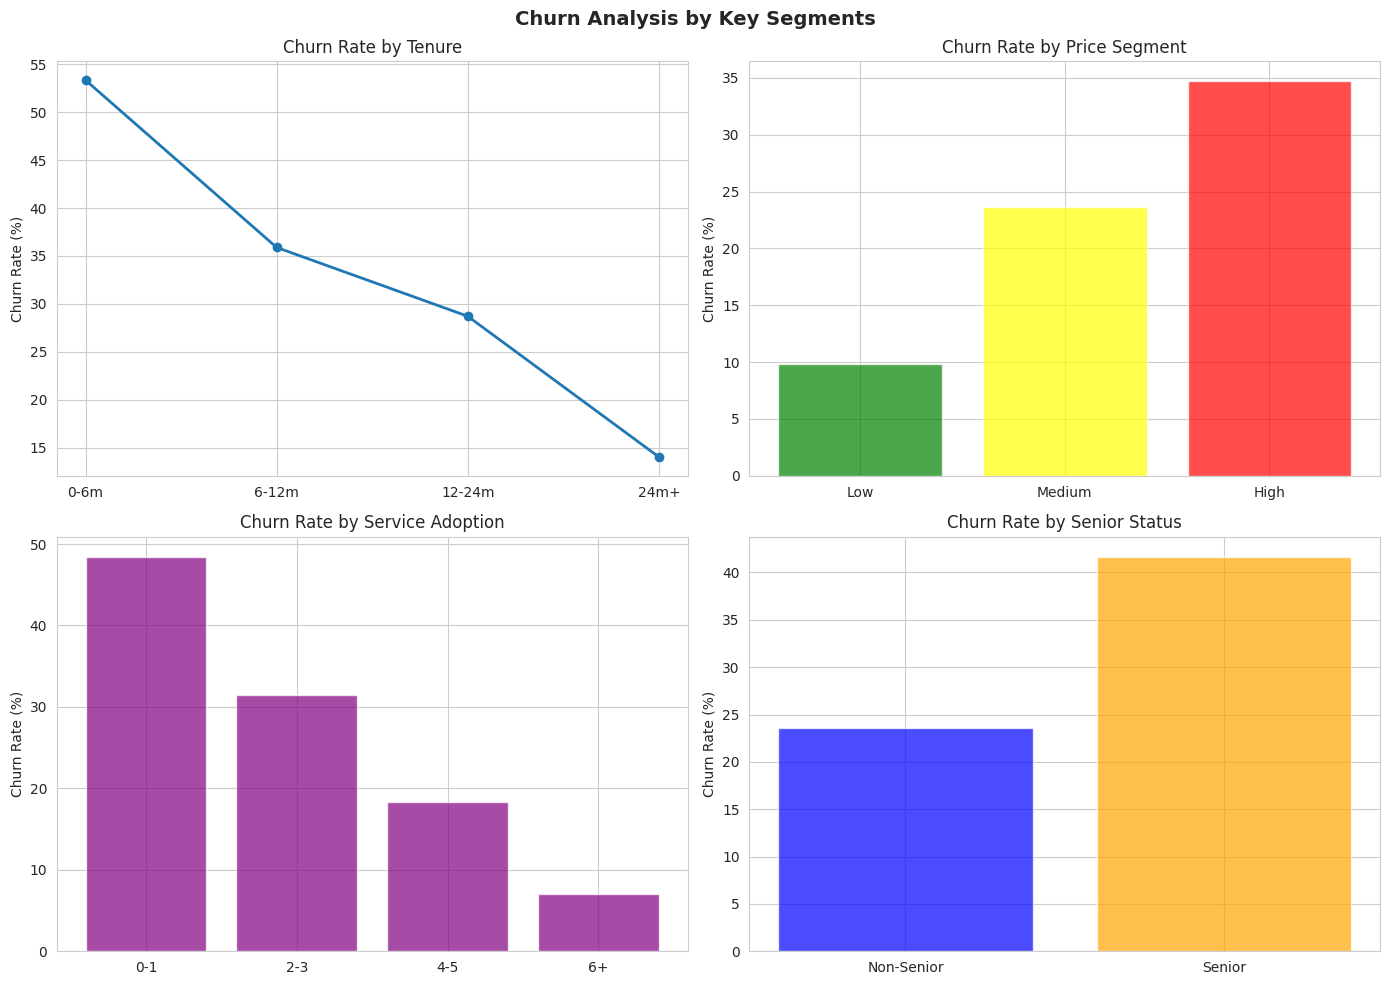

✓ Segmentation Analysis Complete


In [54]:
# Type 3: Segmentation & Advanced Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Churn Analysis by Key Segments', fontsize=14, fontweight='bold')

# Churn by Tenure
tenure_bins = pd.cut(df['tenure'], bins=[0, 6, 12, 24, 72])
churn_by_tenure = df.groupby(tenure_bins)['Churn'].mean() * 100
axes[0, 0].plot(range(len(churn_by_tenure)), churn_by_tenure.values, marker='o', linewidth=2)
axes[0, 0].set_xticks(range(len(churn_by_tenure)))
axes[0, 0].set_xticklabels(['0-6m', '6-12m', '12-24m', '24m+'])
axes[0, 0].set_title('Churn Rate by Tenure')
axes[0, 0].set_ylabel('Churn Rate (%)')

# Churn by Monthly Charges
charge_bins = pd.cut(df['MonthlyCharges'], bins=[0, 30, 65, 150])
churn_by_charges = df.groupby(charge_bins)['Churn'].mean() * 100
axes[0, 1].bar(range(len(churn_by_charges)), churn_by_charges.values, color=['green', 'yellow', 'red'], alpha=0.7)
axes[0, 1].set_xticks(range(len(churn_by_charges)))
axes[0, 1].set_xticklabels(['Low', 'Medium', 'High'])
axes[0, 1].set_title('Churn Rate by Price Segment')
axes[0, 1].set_ylabel('Churn Rate (%)')

# Churn by Service Count
service_bins = pd.cut(df['ServiceCount'], bins=[-1, 1, 3, 5, 8])
churn_by_service = df.groupby(service_bins)['Churn'].mean() * 100
axes[1, 0].bar(range(len(churn_by_service)), churn_by_service.values, color='purple', alpha=0.7)
axes[1, 0].set_xticks(range(len(churn_by_service)))
axes[1, 0].set_xticklabels(['0-1', '2-3', '4-5', '6+'])
axes[1, 0].set_title('Churn Rate by Service Adoption')
axes[1, 0].set_ylabel('Churn Rate (%)')

# Churn by Senior Status
churn_by_senior = df.groupby('SeniorCitizen')['Churn'].mean() * 100
axes[1, 1].bar(['Non-Senior', 'Senior'], churn_by_senior.values, color=['blue', 'orange'], alpha=0.7)
axes[1, 1].set_title('Churn Rate by Senior Status')
axes[1, 1].set_ylabel('Churn Rate (%)')

plt.tight_layout()
plt.show()
print('✓ Segmentation Analysis Complete')


## 9. DATA PREPARATION FOR MACHINE LEARNING

In [55]:
# Prepare features and target
X = df.drop(['Churn', 'customerID'], axis=1)
y = df['Churn']

print(f'Features: {X.shape[1]}, Samples: {X.shape[0]}')
print(f'\nChurn Distribution:')
print(y.value_counts())
print(f'\nChurn Rate: {y.mean():.2%}')

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Handle class imbalance
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f'\nTraining set: {X_train_scaled.shape}')
print(f'After SMOTE: {X_train_smote.shape}')


Features: 36, Samples: 7043

Churn Distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn Rate: 26.54%

Training set: (4507, 36)
After SMOTE: (6622, 36)


> **Note on the split.** Data are split 64 / 16 / 20 (train / validation / test), stratified on churn. The scaler and SMOTE are fitted on the training split only, so no information from the test set leaks into training. The validation split is created but not used in this notebook; it is available for threshold tuning in future work.

## 10. MACHINE LEARNING MODELS

In [56]:
print('Model 1: Logistic Regression')
param_grid_lr = {'C': [0.001, 0.01, 0.1, 1, 10], 'penalty': ['l1', 'l2']}
lr = LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')
gs_lr = GridSearchCV(lr, param_grid_lr, cv=5, scoring='f1')
gs_lr.fit(X_train_smote, y_train_smote)
lr_best = gs_lr.best_estimator_
print(f'Best params: {gs_lr.best_params_}')
print(f'CV F1 Score: {gs_lr.best_score_:.4f}')

y_pred_lr = lr_best.predict(X_test_scaled)
y_pred_proba_lr = lr_best.predict_proba(X_test_scaled)[:, 1]
print('\n✓ Logistic Regression trained')


Model 1: Logistic Regression
Best params: {'C': 0.01, 'penalty': 'l2'}
CV F1 Score: 0.7909

✓ Logistic Regression trained


In [57]:
print('Model 2: Random Forest')
param_grid_rf = {'n_estimators': [100, 200], 'max_depth': [10, 20], 'min_samples_split': [5, 10]}
rf = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')
gs_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='f1')
gs_rf.fit(X_train_scaled, y_train)
rf_best = gs_rf.best_estimator_
print(f'Best params: {gs_rf.best_params_}')
print(f'CV F1 Score: {gs_rf.best_score_:.4f}')

y_pred_rf = rf_best.predict(X_test_scaled)
y_pred_proba_rf = rf_best.predict_proba(X_test_scaled)[:, 1]
print('\n✓ Random Forest trained')


Model 2: Random Forest
Best params: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 100}
CV F1 Score: 0.6339

✓ Random Forest trained


In [58]:
print('Model 3: XGBoost')
scale_pos = (len(y_train) - y_train.sum()) / y_train.sum()
param_grid_xgb = {'n_estimators': [100, 200], 'max_depth': [4, 6], 'learning_rate': [0.01, 0.1]}
xgb_model = xgb.XGBClassifier(random_state=42, scale_pos_weight=scale_pos, eval_metric='logloss', use_label_encoder=False)
gs_xgb = GridSearchCV(xgb_model, param_grid_xgb, cv=5, scoring='f1')
gs_xgb.fit(X_train_scaled, y_train)
xgb_best = gs_xgb.best_estimator_
print(f'Best params: {gs_xgb.best_params_}')
print(f'CV F1 Score: {gs_xgb.best_score_:.4f}')

y_pred_xgb = xgb_best.predict(X_test_scaled)
y_pred_proba_xgb = xgb_best.predict_proba(X_test_scaled)[:, 1]
print('\n✓ XGBoost trained')


Model 3: XGBoost
Best params: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 200}
CV F1 Score: 0.6287

✓ XGBoost trained


> **Reading the CV scores.** Logistic Regression's cross-validated F1 (0.79) is computed on SMOTE-balanced training data, where half the samples are churners and some are synthetic, so it is not comparable with the Random Forest and XGBoost CV scores (≈ 0.63), which use the real class balance. The test-set comparison in Section 11 is the fair one.

## 11. MODEL PERFORMANCE COMPARISON


Model Performance Comparison:
     Accuracy  Precision  Recall      F1     AUC
LR     0.7502     0.5198  0.7727  0.6215  0.8441
RF     0.7665     0.5446  0.7353  0.6257  0.8376
XGB    0.7452     0.5130  0.7941  0.6233  0.8423


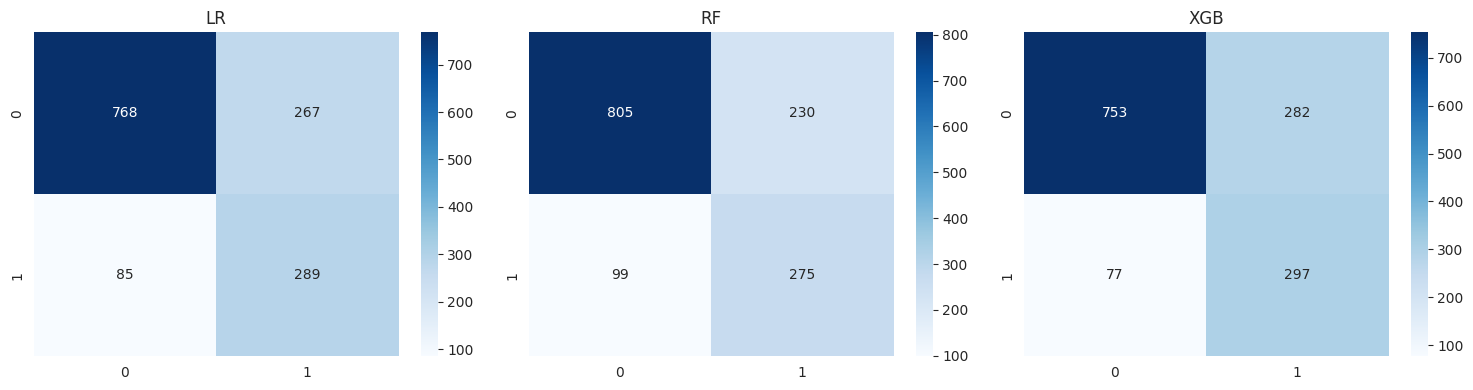

✓ Model Comparison Complete


In [59]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

# Evaluation metrics
results = {}
for name, y_pred, y_proba in [('LR', y_pred_lr, y_pred_proba_lr),
                                ('RF', y_pred_rf, y_pred_proba_rf),
                                ('XGB', y_pred_xgb, y_pred_proba_xgb)]:
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_proba)
    }

comp_df = pd.DataFrame(results).T
print('\nModel Performance Comparison:')
print(comp_df.round(4))

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, (name, y_pred) in enumerate([('LR', y_pred_lr), ('RF', y_pred_rf), ('XGB', y_pred_xgb)]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[idx], cmap='Blues')
    axes[idx].set_title(f'{name}')
plt.tight_layout()
plt.show()
print('✓ Model Comparison Complete')


> **Interpretation.** On the 1,409-customer test set the three models are practically tied: F1 0.622-0.626 and ROC-AUC 0.838-0.844. Random Forest has the highest F1 (0.626) and accuracy (76.7 %); Logistic Regression has the best AUC (0.844); XGBoost has the highest recall (79.4 %). Because all were tuned for F1 with class balancing, they deliberately trade precision (≈ 0.52) for recall, catching three out of four churners at the cost of some false alarms - usually the right trade-off when a retention offer is cheaper than a lost customer.

## 12. FEATURE IMPORTANCE ANALYSIS

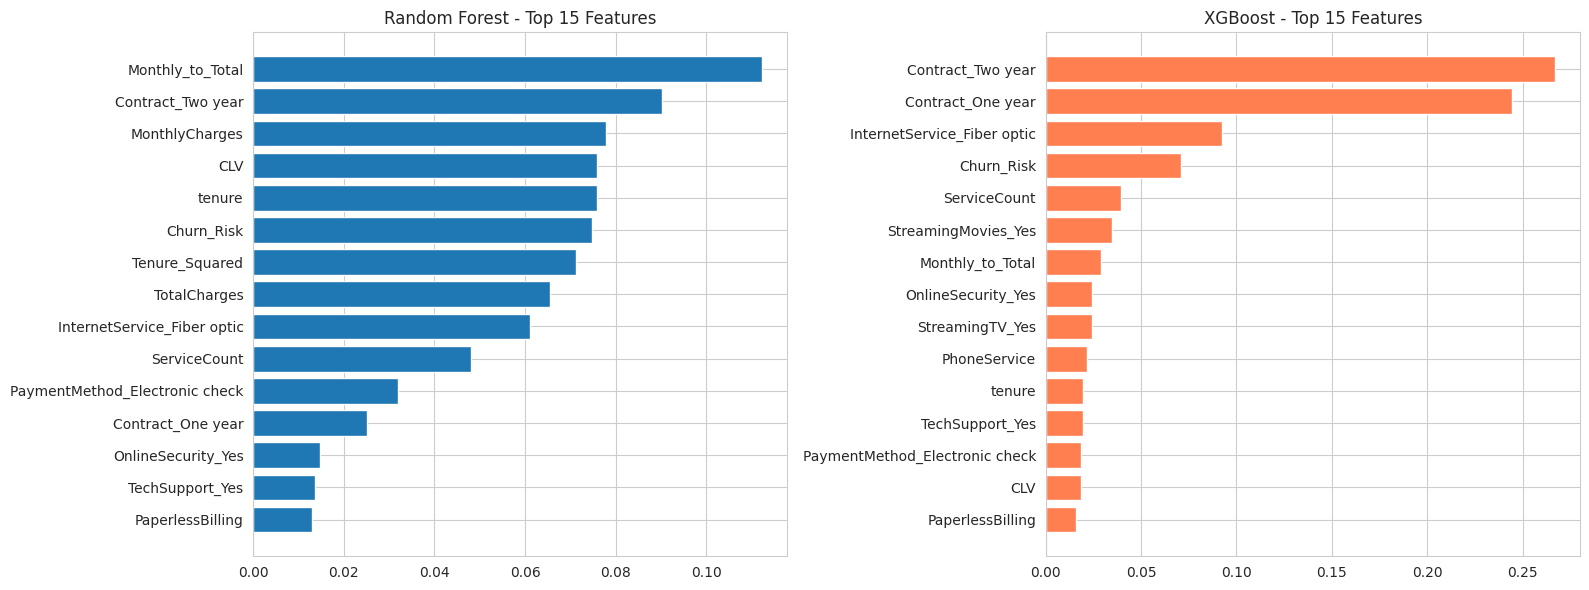

✓ Feature Importance Complete


In [60]:
# Feature importance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest
rf_imp = pd.DataFrame({'Feature': X_train.columns, 'Importance': rf_best.feature_importances_}).sort_values('Importance', ascending=False).head(15)
axes[0].barh(range(len(rf_imp)), rf_imp['Importance'].values)
axes[0].set_yticks(range(len(rf_imp)))
axes[0].set_yticklabels(rf_imp['Feature'].values)
axes[0].set_title('Random Forest - Top 15 Features')
axes[0].invert_yaxis()

# XGBoost
xgb_imp = pd.DataFrame({'Feature': X_train.columns, 'Importance': xgb_best.feature_importances_}).sort_values('Importance', ascending=False).head(15)
axes[1].barh(range(len(xgb_imp)), xgb_imp['Importance'].values, color='coral')
axes[1].set_yticks(range(len(xgb_imp)))
axes[1].set_yticklabels(xgb_imp['Feature'].values)
axes[1].set_title('XGBoost - Top 15 Features')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()
print('✓ Feature Importance Complete')


## 13. FEATURE ENGINEERING IMPACT ANALYSIS


Feature Engineering Impact:
              Model  Accuracy      F1
0     RF (Original)    0.7615  0.5862
1   RF (Engineered)    0.7665  0.6257
2    XGB (Original)    0.7885  0.5270
3  XGB (Engineered)    0.7452  0.6233


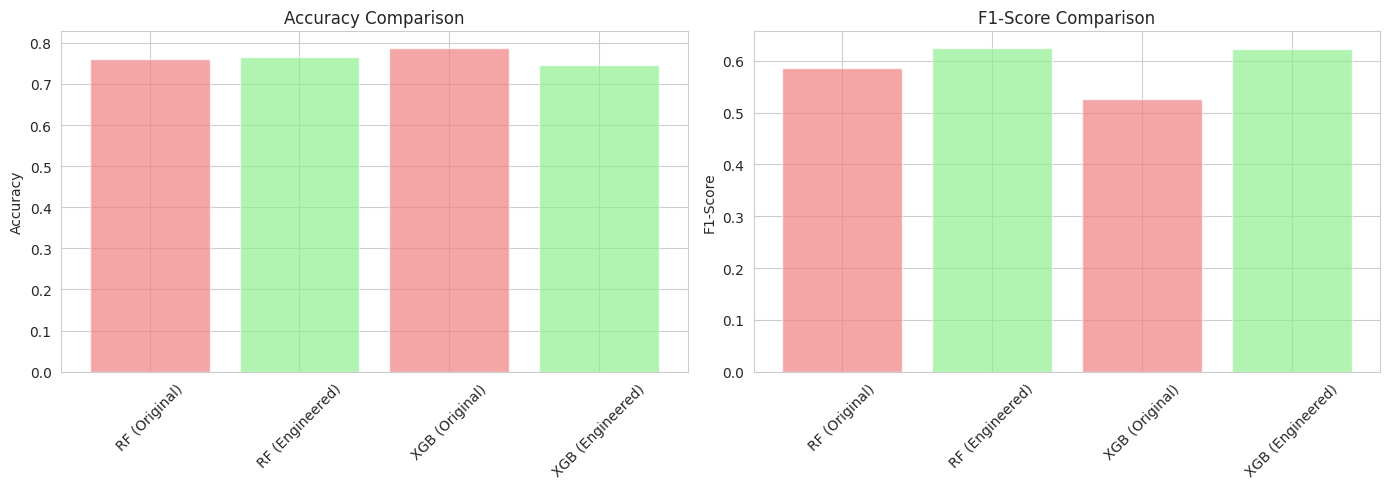

✓ Feature Engineering Impact Complete


In [61]:
# Compare with original features
original_cols = [col for col in ['tenure', 'SeniorCitizen', 'MonthlyCharges', 'TotalCharges', 'gender', 'Partner'] if col in X_train.columns]
X_train_orig = X_train_scaled[original_cols]
X_test_orig = X_test_scaled[original_cols]

# Train RF and XGB with original features
rf_orig = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced')
rf_orig.fit(X_train_orig, y_train)
y_pred_rf_orig = rf_orig.predict(X_test_orig)

xgb_orig = xgb.XGBClassifier(n_estimators=100, max_depth=4, random_state=42, eval_metric='logloss', use_label_encoder=False)
xgb_orig.fit(X_train_orig, y_train)
y_pred_xgb_orig = xgb_orig.predict(X_test_orig)

# Compare
fe_comp = pd.DataFrame({
    'Model': ['RF (Original)', 'RF (Engineered)', 'XGB (Original)', 'XGB (Engineered)'],
    'Accuracy': [accuracy_score(y_test, y_pred_rf_orig), accuracy_score(y_test, y_pred_rf),
                 accuracy_score(y_test, y_pred_xgb_orig), accuracy_score(y_test, y_pred_xgb)],
    'F1': [f1_score(y_test, y_pred_rf_orig), f1_score(y_test, y_pred_rf),
           f1_score(y_test, y_pred_xgb_orig), f1_score(y_test, y_pred_xgb)]
})

print('\nFeature Engineering Impact:')
print(fe_comp.round(4))

# Visualization
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].bar(fe_comp['Model'], fe_comp['Accuracy'], color=['lightcoral', 'lightgreen', 'lightcoral', 'lightgreen'], alpha=0.7)
ax[0].set_ylabel('Accuracy')
ax[0].set_title('Accuracy Comparison')
ax[0].tick_params(axis='x', rotation=45)

ax[1].bar(fe_comp['Model'], fe_comp['F1'], color=['lightcoral', 'lightgreen', 'lightcoral', 'lightgreen'], alpha=0.7)
ax[1].set_ylabel('F1-Score')
ax[1].set_title('F1-Score Comparison')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
print('✓ Feature Engineering Impact Complete')


> **Caveat.** The "original" baseline here uses only six raw columns, and the original XGBoost model has no class weighting, so this comparison measures the value of the full encoded and engineered feature set together rather than the engineered features alone. The F1 gains (+0.040 for Random Forest, +0.096 for XGBoost) are real, but XGBoost's accuracy falls (0.789 → 0.745) because class weighting shifts it toward catching more churners.

## 14. BUSINESS INSIGHTS & RECOMMENDATIONS

In [62]:
print('='*80)
print('KEY BUSINESS INSIGHTS')
print('='*80)

print('\n1. CHURN PATTERNS:')
print(f'   - Overall Churn Rate: {y.mean():.2%}')
print(f'   - Early Churn (<6mo): {df[df.tenure < 6]["Churn"].mean():.2%}')
print(f'   - Loyal Customers (24+mo): {df[df.tenure >= 24]["Churn"].mean():.2%}')

print('\n2. MODEL PERFORMANCE:')
best_idx = comp_df['F1'].idxmax()
print(f'   - Best Model: {best_idx}')
print(f'   - F1-Score: {comp_df.loc[best_idx, "F1"]:.4f}')
print(f'   - Recall: {comp_df.loc[best_idx, "Recall"]:.4f}')

print('\n3. FEATURE ENGINEERING IMPACT:')
rf_improve = (fe_comp.loc[1, 'F1'] - fe_comp.loc[0, 'F1']) * 100
xgb_improve = (fe_comp.loc[3, 'F1'] - fe_comp.loc[2, 'F1']) * 100
print(f'   - RF F1 Improvement: {rf_improve:+.2f}%')
print(f'   - XGB F1 Improvement: {xgb_improve:+.2f}%')

print('\n4. RETENTION RECOMMENDATIONS:')
print('   - Focus on first 6 months of customer lifecycle')
print('   - Increase service bundling to boost adoption')
print('   - Offer contract incentives (month-to-month -> annual)')
print('   - Monitor high-risk segments proactively')

print('\n' + '='*80)
print('ANALYSIS COMPLETE')
print('='*80)


KEY BUSINESS INSIGHTS

1. CHURN PATTERNS:
   - Overall Churn Rate: 26.54%
   - Early Churn (<6mo): 54.27%
   - Loyal Customers (24+mo): 14.29%

2. MODEL PERFORMANCE:
   - Best Model: RF
   - F1-Score: 0.6257
   - Recall: 0.7353

3. FEATURE ENGINEERING IMPACT:
   - RF F1 Improvement: +3.95%
   - XGB F1 Improvement: +9.63%

4. RETENTION RECOMMENDATIONS:
   - Focus on first 6 months of customer lifecycle
   - Increase service bundling to boost adoption
   - Offer contract incentives (month-to-month -> annual)
   - Monitor high-risk segments proactively

ANALYSIS COMPLETE


## 15. CONCLUSIONS & NEXT STEPS

- **Who churns:** customers in their first six months (54 % churn) and customers on month-to-month contracts (43 % churn, against 11 % on one-year and 3 % on two-year contracts, from the Query 3 output); customers with 24+ months of tenure churn at only 14 %. Month-to-month fibre-optic customers are the riskiest segment (55 % churn).
- **Model performance:** Logistic Regression, Random Forest and XGBoost reach F1 ≈ 0.62-0.63 and ROC-AUC ≈ 0.84 on held-out data, recovering 74-79 % of churners. The simplest model (Logistic Regression) is as good as the ensembles and is the easiest to explain to a business audience.
- **Next steps:** use the validation split to tune the decision threshold against the cost of a retention offer, add cross-validated confidence intervals, and explain individual predictions with SHAP for targeted retention campaigns.